# 小红书用户收入影响因素回归分析

## 项目介绍

本项目基于小红书平台 **29,451 条用户记录**，通过回归分析方法探索影响用户消费金额（revenue）的关键因素。通过数据预处理、探索性分析、特征工程和多元线性回归建模，识别出对用户收入贡献最大的变量，并据此提出可操作的运营建议。

## 数据说明

| 字段 | 类型 | 说明 |
|------|------|------|
| `revenue` | 数值 | 用户消费金额（**目标变量**） |
| `gender` | 类别 | 性别 |
| `age` | 数值 | 年龄 |
| `engaged_last_30` | 二值 | 近 30 天是否活跃（0/1） |
| `lifecycle` | 类别 | 用户生命周期阶段（A / B / C …） |
| `days_since_last_order` | 数值 | 距上次下单天数 |
| `previous_order_amount` | 数值 | 历史订单金额 |
| `3rd_party_stores` | 二值 | 是否使用第三方店铺（0/1） |

## 关键指标说明

| 指标 | 含义 |
|------|------|
| **R²（决定系数）** | 模型解释目标变量方差的比例，越接近 1 越好 |
| **Adjusted R²** | 考虑特征数量的修正 R²，防止过拟合 |
| **RMSE（均方根误差）** | 预测值与真实值之间的平均偏差，单位与目标变量一致 |
| **MAE（平均绝对误差）** | 预测误差的平均绝对值 |
| **p 值** | 回归系数的统计显著性检验，p < 0.05 表示显著 |
| **VIF（方差膨胀因子）** | 检测多重共线性，VIF > 10 提示严重共线性 |
| **相关系数（r）** | 两变量间线性关系的强度与方向，范围 [-1, 1] |

## 核心结论与运营建议

> 本项目的核心发现与运营建议汇总在 [notebook 末尾](#5-结论与建议)，每条结论均附有回归系数、p 值、相关系数等数据支撑。请先顺序运行全部代码单元，结论将在最后自动生成。

## 目录

1. [数据预处理](#1-数据预处理)
2. [探索性数据分析（EDA）](#2-探索性数据分析eda)
3. [特征工程](#3-特征工程)
4. [回归建模](#4-回归建模)
5. [结论与建议](#5-结论与建议)

<a id="1-数据预处理"></a>
# 1. 数据预处理

In [1]:
# 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print("库导入完成 ✓")

库导入完成 ✓


In [2]:
# 读取数据
df = pd.read_csv('redNew.csv')

# 清理列名中的多余空格
df.columns = df.columns.str.strip()

print(f"数据集形状: {df.shape}")
print(f"\n{'='*50}")
print("前 5 行数据:")
df.head()

数据集形状: (29452, 8)

前 5 行数据:


,revenue,gender,age,engaged_last_30,lifecycle,days_since_last_order,previous_order_amount,3rd_party_stores
0,72.98,1.0,59.0,0.0,B,4.26,2343.870,0
1,200.99,1.0,51.0,0.0,A,0.94,8539.872,0
2,69.98,1.0,79.0,0.0,C,4.29,1687.646,1
3,649.99,NaN,NaN,NaN,C,14.90,3498.846,0
4,83.59,NaN,NaN,NaN,C,21.13,3968.490,4


In [3]:
# 数据类型与基本信息
print("数据类型:")
print(df.dtypes)
print(f"\n{'='*50}")
print("\n缺失值统计:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例(%)': missing_pct})
print(missing_df[missing_df['缺失数量'] > 0])
print(f"\n总缺失值: {df.isnull().sum().sum()}")

print(f"\n{'='*50}")
print(f"\n重复值数量: {df.duplicated().sum()}")

数据类型:
revenue                  float64
gender                   float64
age                      float64
engaged_last_30          float64
lifecycle                 object
days_since_last_order    float64
previous_order_amount    float64
3rd_party_stores           int64
dtype: object


缺失值统计:
                  缺失数量  缺失比例(%)
gender           11729    39.82
age              12736    43.24
engaged_last_30  11729    39.82

总缺失值: 36194


重复值数量: 1


In [4]:
# 处理缺失值：删除含缺失值的行（缺失比例较低时适用）
print(f"处理前样本数: {len(df)}")
df_clean = df.dropna().copy()
print(f"处理后样本数: {len(df_clean)}")
print(f"删除样本数: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)")

# 删除重复值
dup_count = df_clean.duplicated().sum()
if dup_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"\n删除重复值: {dup_count} 条")

# 数据类型转换
df_clean['gender'] = df_clean['gender'].astype(int)
df_clean['engaged_last_30'] = df_clean['engaged_last_30'].astype(int)
df_clean['3rd_party_stores'] = df_clean['3rd_party_stores'].astype(int)

print(f"\n最终数据集形状: {df_clean.shape}")

处理前样本数: 29452
处理后样本数: 16716
删除样本数: 12736 (43.24%)

最终数据集形状: (16716, 8)


In [ ]:
# 1.5 异常值检测与处理（IQR方法）
print("=" * 60)
print("异常值检测与处理（IQR方法）")
print("=" * 60)

num_cols = ['revenue', 'age', 'days_since_last_order', 'previous_order_amount']

print(f"\n处理前样本数: {len(df_clean)}")
print(f"\n{'特征':<25} {'下界':>10} {'上界':>10} {'异常值数':>10} {'占比':>8}")
print("-" * 65)

outlier_mask = pd.Series([False] * len(df_clean), index=df_clean.index)

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    col_outliers = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_mask = outlier_mask | col_outliers
    n_outliers = col_outliers.sum()
    pct = n_outliers / len(df_clean) * 100
    print(f"{col:<25} {lower:>10.2f} {upper:>10.2f} {n_outliers:>10d} {pct:>7.2f}%")

total_outliers = outlier_mask.sum()
print(f"\n综合异常样本数: {total_outliers} ({total_outliers/len(df_clean)*100:.2f}%)")

# 保留处理前的统计信息用于对比
stats_before = df_clean[num_cols].describe().round(2)

# 移除异常值
df_clean = df_clean[~outlier_mask].copy()

stats_after = df_clean[num_cols].describe().round(2)

print(f"处理后样本数: {len(df_clean)}")
print(f"\n--- 处理前后关键统计量对比 ---")
for col in num_cols:
    print(f"\n【{col}】")
    print(f"  均值: {stats_before.loc['mean', col]:.2f} → {stats_after.loc['mean', col]:.2f}")
    print(f"  标准差: {stats_before.loc['std', col]:.2f} → {stats_after.loc['std', col]:.2f}")
    print(f"  最大值: {stats_before.loc['max', col]:.2f} → {stats_after.loc['max', col]:.2f}")

print("\n✓ 异常值处理完成，数据分布更加稳健")

In [5]:
# 基础描述性统计
df_clean.describe().round(2)

,revenue,gender,age,engaged_last_30,days_since_last_order,previous_order_amount,3rd_party_stores
count,16716.00,16716.00,16716.00,16716.00,16716.00,16716.00,16716.00
mean,375.21,0.96,60.40,0.07,7.25,2579.65,1.98
std,624.98,0.20,14.82,0.25,6.20,2490.51,3.27
min,0.02,0.00,18.00,0.00,0.13,0.00,0.00
25%,71.94,1.00,50.00,0.00,2.10,903.62,0.00
50%,164.98,1.00,60.00,0.00,5.52,1852.95,0.00
75%,479.99,1.00,70.00,0.00,11.19,3394.95,3.00
max,29080.80,1.00,99.00,1.00,23.71,11597.90,10.00


<a id="2-探索性数据分析eda"></a>
# 2. 探索性数据分析（EDA）

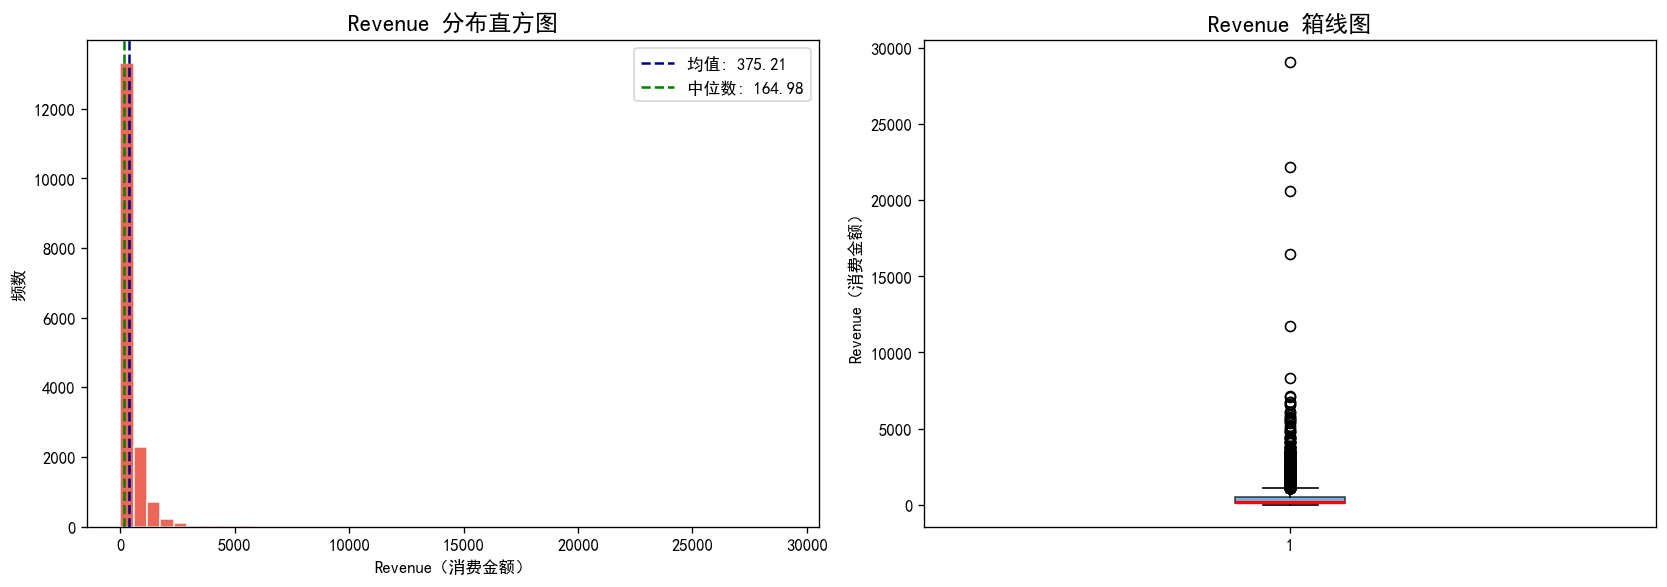

偏度 (Skewness): 13.9501
峰度 (Kurtosis): 465.3937


In [6]:
# 2.1 目标变量 revenue 分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
axes[0].hist(df_clean['revenue'], bins=50, color='#E74C3C', edgecolor='white', alpha=0.85)
axes[0].set_title('Revenue 分布直方图', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenue（消费金额）')
axes[0].set_ylabel('频数')
axes[0].axvline(df_clean['revenue'].mean(), color='navy', linestyle='--', label=f"均值: {df_clean['revenue'].mean():.2f}")
axes[0].axvline(df_clean['revenue'].median(), color='green', linestyle='--', label=f"中位数: {df_clean['revenue'].median():.2f}")
axes[0].legend()

# 箱线图
bp = axes[1].boxplot(df_clean['revenue'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='#3498DB', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Revenue 箱线图', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue（消费金额）')

plt.tight_layout()
plt.show()

print(f"偏度 (Skewness): {df_clean['revenue'].skew():.4f}")
print(f"峰度 (Kurtosis): {df_clean['revenue'].kurt():.4f}")

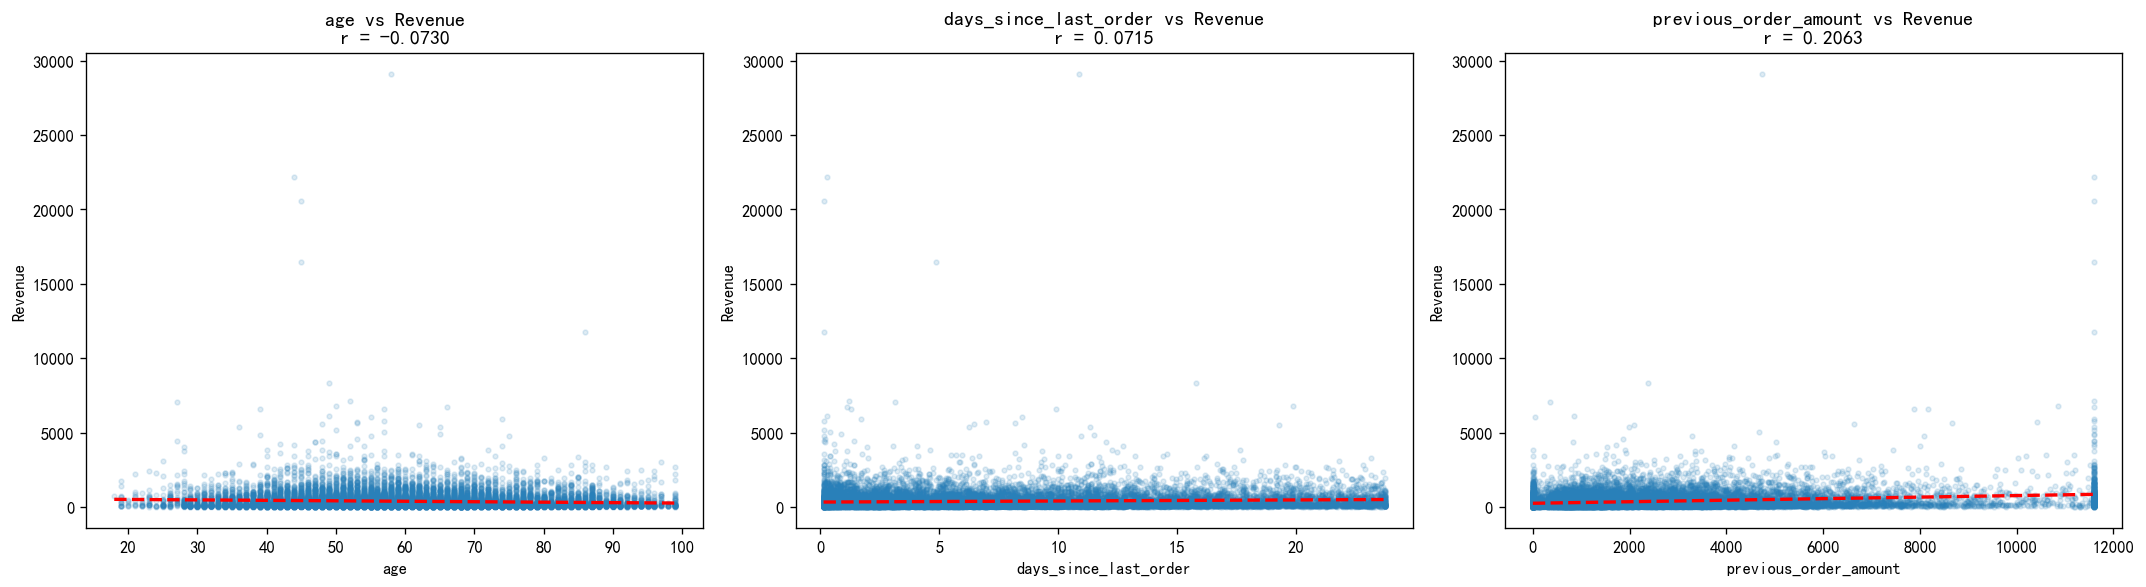

In [7]:
# 2.2 数值特征与 revenue 的散点图
num_features = ['age', 'days_since_last_order', 'previous_order_amount']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_features):
    axes[i].scatter(df_clean[col], df_clean['revenue'], alpha=0.15, s=8, color='#2980B9')
    # 添加趋势线
    z = np.polyfit(df_clean[col], df_clean['revenue'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    corr = df_clean[col].corr(df_clean['revenue'])
    axes[i].set_title(f'{col} vs Revenue\nr = {corr:.4f}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

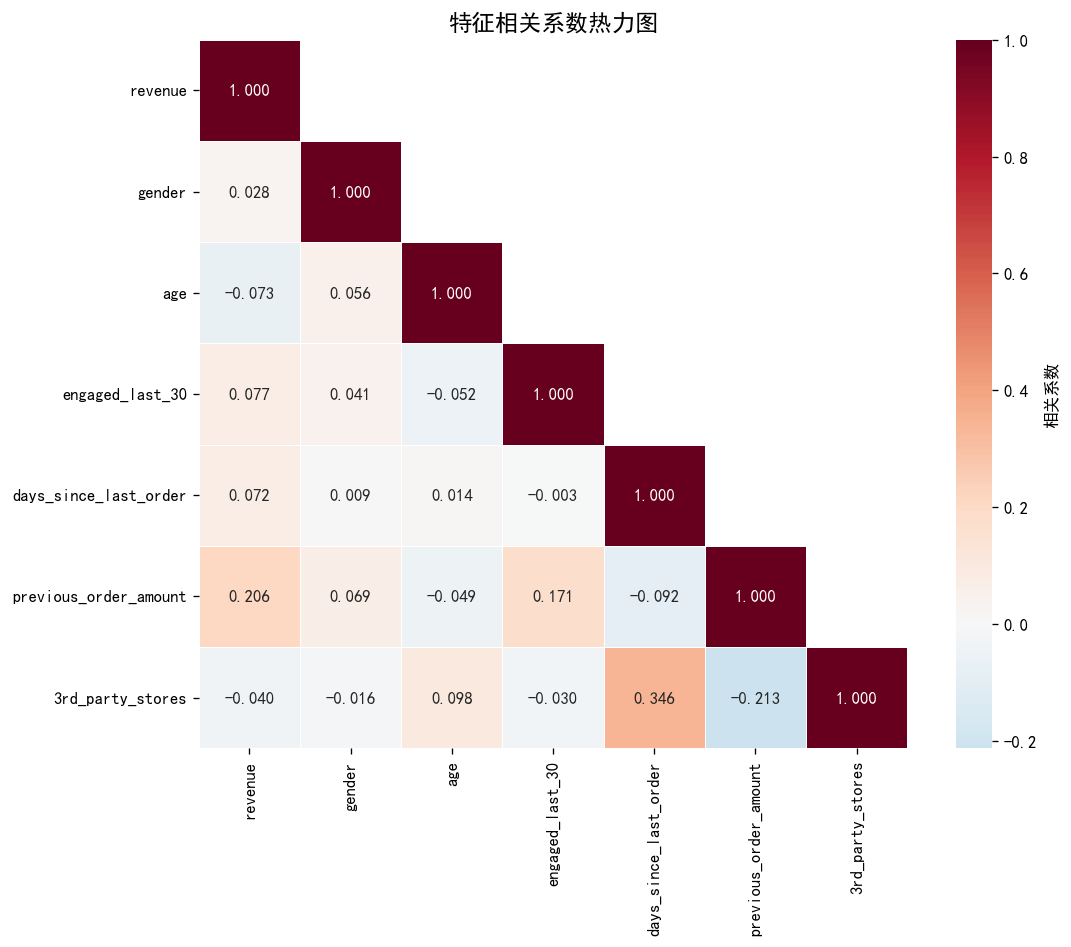

In [8]:
# 2.3 相关系数热力图
numeric_cols = ['revenue', 'gender', 'age', 'engaged_last_30', 'days_since_last_order',
                'previous_order_amount', '3rd_party_stores']
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': '相关系数'})
ax.set_title('特征相关系数热力图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

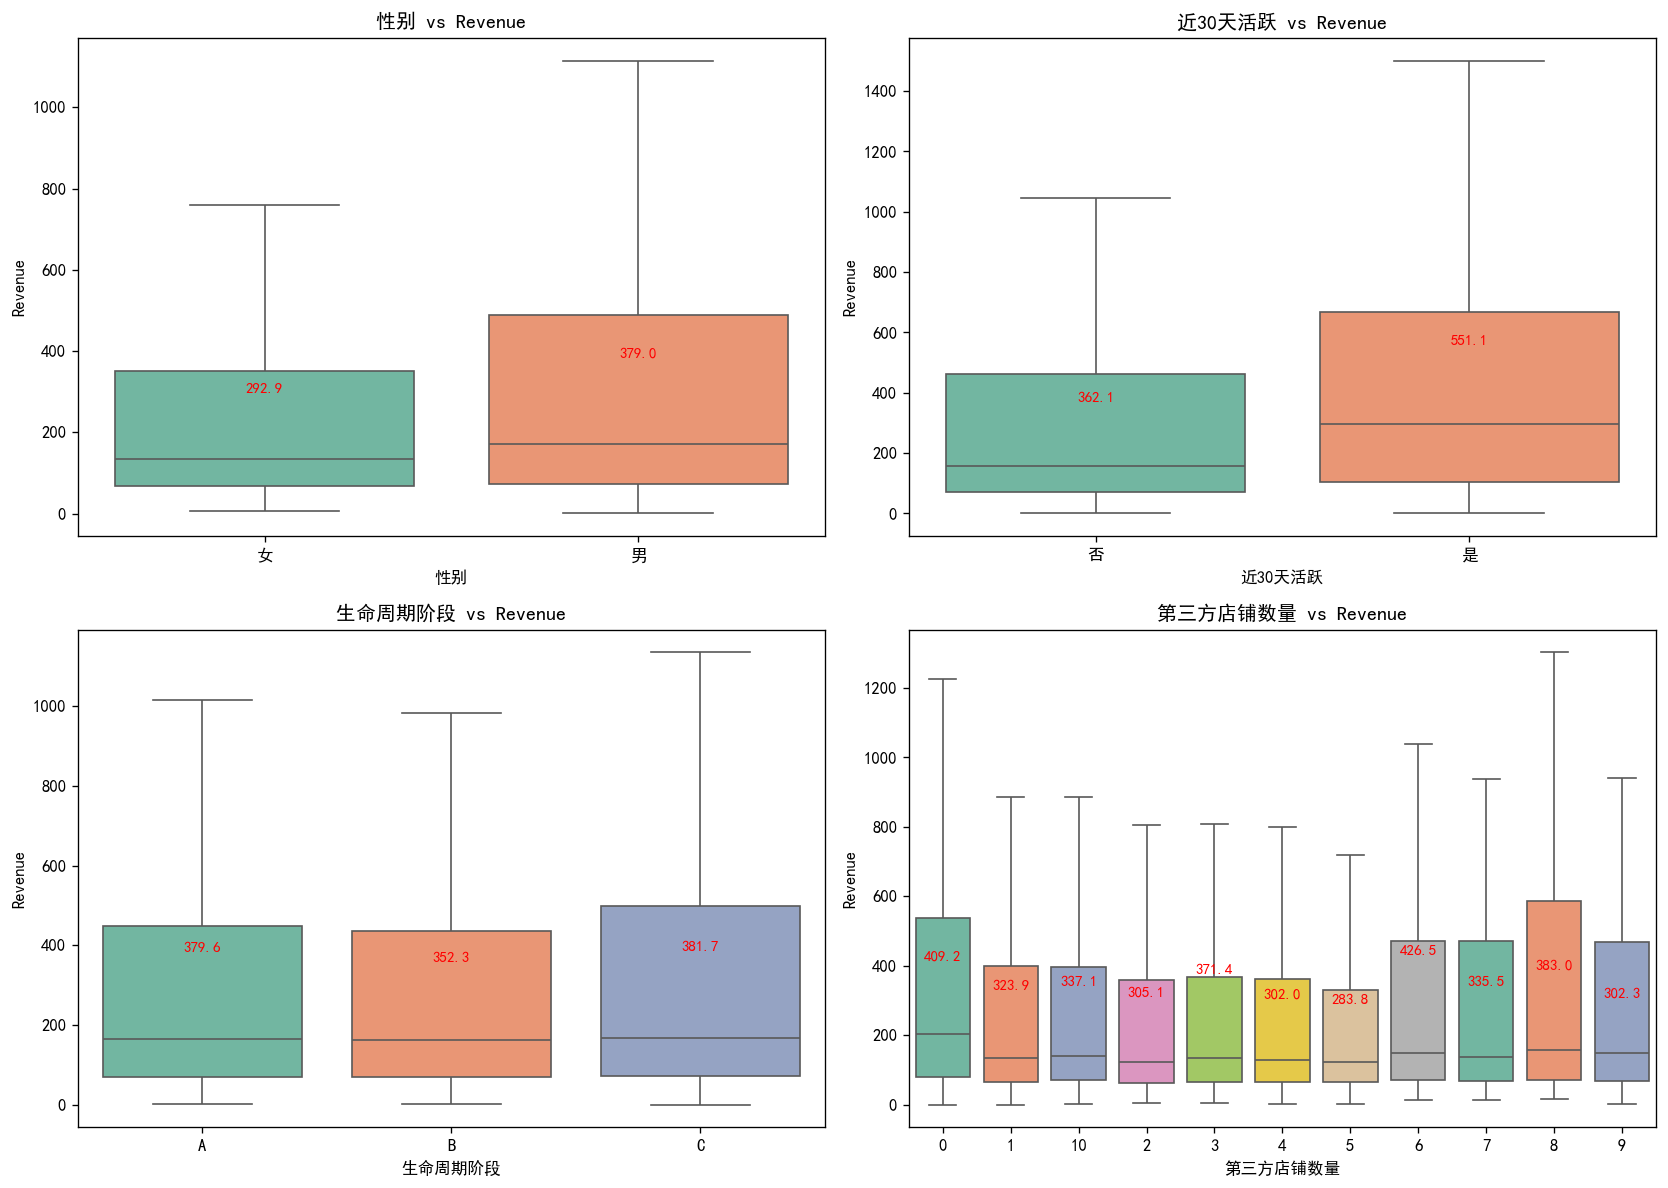

In [9]:
# 2.4 类别特征与 revenue 的分组箱线图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_features = [
    ('gender', '性别', {0: '女', 1: '男'}),
    ('engaged_last_30', '近30天活跃', {0: '否', 1: '是'}),
    ('lifecycle', '生命周期阶段', None),
    ('3rd_party_stores', '第三方店铺数量', None)
]

for idx, (col, title, label_map) in enumerate(cat_features):
    ax = axes[idx // 2][idx % 2]
    plot_data = df_clean[[col, 'revenue']].copy()
    # 先转为合适类型，再做标签映射
    if label_map:
        plot_data[col] = plot_data[col].astype(int).map(label_map)
    else:
        plot_data[col] = plot_data[col].astype(str)
    order = sorted(plot_data[col].unique())
    sns.boxplot(x=col, y='revenue', data=plot_data, ax=ax, order=order,
                palette='Set2', showfliers=False)
    ax.set_title(f'{title} vs Revenue', fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Revenue')
    # 添加各组均值标注
    means = plot_data.groupby(col)['revenue'].mean()
    for i, cat in enumerate(order):
        ax.text(i, means[cat], f'{means[cat]:.1f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9, color='red')

plt.tight_layout()
plt.show()

In [ ]:
# 2.5 用户分群分析：lifecycle × engaged_last_30 交叉分析
print("=" * 60)
print("用户分群分析：生命周期阶段 × 近30天活跃度")
print("=" * 60)

# 构建交叉分群
segment_revenue = df_clean.groupby(['lifecycle', 'engaged_last_30'])['revenue'].agg(['mean', 'count']).reset_index()
segment_revenue.columns = ['lifecycle', 'engaged_last_30', 'avg_revenue', 'user_count']

# 标签映射
segment_revenue['活跃状态'] = segment_revenue['engaged_last_30'].map({0: '非活跃', 1: '活跃'})

print("\n各分群用户数及平均收入:")
for _, row in segment_revenue.iterrows():
    active = '活跃' if row['engaged_last_30'] == 1 else '非活跃'
    print(f"  {row['lifecycle']} × {active}: 用户数={int(row['user_count'])}, 平均收入={row['avg_revenue']:.2f}")

# 热力图：平均收入
pivot_revenue = df_clean.pivot_table(values='revenue', index='lifecycle', 
                                      columns='engaged_last_30', aggfunc='mean')
pivot_revenue.columns = ['非活跃', '活跃']

pivot_count = df_clean.pivot_table(values='revenue', index='lifecycle', 
                                    columns='engaged_last_30', aggfunc='count')
pivot_count.columns = ['非活跃', '活跃']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 热力图1：平均收入
sns.heatmap(pivot_revenue, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '平均收入'})
axes[0].set_title('各分群平均收入（Revenue）', fontsize=13, fontweight='bold')
axes[0].set_xlabel('近30天活跃状态')
axes[0].set_ylabel('生命周期阶段')

# 热力图2：用户数
sns.heatmap(pivot_count, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar_kws={'label': '用户数'})
axes[1].set_title('各分群用户数量', fontsize=13, fontweight='bold')
axes[1].set_xlabel('近30天活跃状态')
axes[1].set_ylabel('生命周期阶段')

plt.suptitle('用户分群精细化分析（生命周期 × 活跃度）', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 业务洞察
print("\n--- 分群洞察 ---")
best_segment = segment_revenue.loc[segment_revenue['avg_revenue'].idxmax()]
worst_segment = segment_revenue.loc[segment_revenue['avg_revenue'].idxmin()]
print(f"最高收入分群: {best_segment['lifecycle']} × {'活跃' if best_segment['engaged_last_30']==1 else '非活跃'}, 平均收入={best_segment['avg_revenue']:.2f}")
print(f"最低收入分群: {worst_segment['lifecycle']} × {'活跃' if worst_segment['engaged_last_30']==1 else '非活跃'}, 平均收入={worst_segment['avg_revenue']:.2f}")
print(f"收入差距: {best_segment['avg_revenue'] - worst_segment['avg_revenue']:.2f}")
print("\n→ 该分群分析可用于制定差异化运营策略，针对不同生命周期和活跃度的用户群体采取精准触达")

<a id="3-特征工程"></a>
# 3. 特征工程

In [10]:
# 3.1 类别变量编码 — lifecycle 独热编码
print("lifecycle 各类别分布:")
print(df_clean['lifecycle'].value_counts())

# 独热编码（drop_first=True 避免多重共线性）
df_model = pd.get_dummies(df_clean, columns=['lifecycle'], drop_first=True, dtype=int)

print(f"\n编码后特征列: {list(df_model.columns)}")
print(f"编码后数据形状: {df_model.shape}")

lifecycle 各类别分布:
lifecycle
C    11084
B     3533
A     2099
Name: count, dtype: int64

编码后特征列: ['revenue', 'gender', 'age', 'engaged_last_30', 'days_since_last_order', 'previous_order_amount', '3rd_party_stores', 'lifecycle_B', 'lifecycle_C']
编码后数据形状: (16716, 9)


In [11]:
# 3.2 定义特征矩阵 X 和目标变量 y
y = df_model['revenue']
X = df_model.drop(columns=['revenue'])

print(f"特征矩阵 X 形状: {X.shape}")
print(f"目标变量 y 形状: {y.shape}")
print(f"\n特征列表: {list(X.columns)}")

特征矩阵 X 形状: (16716, 8)
目标变量 y 形状: (16716,)

特征列表: ['gender', 'age', 'engaged_last_30', 'days_since_last_order', 'previous_order_amount', '3rd_party_stores', 'lifecycle_B', 'lifecycle_C']


In [12]:
# 3.3 多重共线性检查（VIF）
X_with_const = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data['特征'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(X.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("方差膨胀因子 (VIF):")
print(vif_data.to_string(index=False))
print("\n说明: VIF > 10 表示存在严重多重共线性，VIF > 5 需要关注")

方差膨胀因子 (VIF):
                   特征      VIF
          lifecycle_C 3.171748
          lifecycle_B 2.150013
days_since_last_order 1.703985
     3rd_party_stores 1.287986
previous_order_amount 1.088181
      engaged_last_30 1.033928
                  age 1.018882
               gender 1.009821

说明: VIF > 10 表示存在严重多重共线性，VIF > 5 需要关注


<a id="4-回归建模"></a>
# 4. 回归建模

In [13]:
# 4.1 多元线性回归 (OLS)
X_ols = sm.add_constant(X)
model = sm.OLS(y, X_ols).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     127.1
Date:                Sun, 22 Mar 2026   Prob (F-statistic):          7.49e-208
Time:                        00:50:32   Log-Likelihood:            -1.3084e+05
No. Observations:               16716   AIC:                         2.617e+05
Df Residuals:                   16707   BIC:                         2.618e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   310.83

In [ ]:
# 4.2 训练集/测试集划分与模型泛化评估（OLS + Ridge + Lasso）
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, LinearRegression

print("=" * 60)
print("模型泛化能力评估（Train/Test Split 80/20）")
print("=" * 60)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# --- OLS 模型 ---
X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(X_test)
model_ols_split = sm.OLS(y_train, X_train_ols).fit()

y_train_pred_ols = model_ols_split.predict(X_train_ols)
y_test_pred_ols = model_ols_split.predict(X_test_ols)

# --- Ridge 回归 ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)
y_train_pred_ridge = ridge_model.predict(X_train_scaled)
y_test_pred_ridge = ridge_model.predict(X_test_scaled)

# --- Lasso 回归 ---
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_train_pred_lasso = lasso_model.predict(X_train_scaled)
y_test_pred_lasso = lasso_model.predict(X_test_scaled)

# 汇总评估指标
def calc_metrics(y_true, y_pred):
    return {
        'R²': r2_score(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred)
    }

results = []
for name, y_tr_p, y_te_p in [('OLS', y_train_pred_ols, y_test_pred_ols),
                                ('Ridge', y_train_pred_ridge, y_test_pred_ridge),
                                ('Lasso', y_train_pred_lasso, y_test_pred_lasso)]:
    train_m = calc_metrics(y_train, y_tr_p)
    test_m = calc_metrics(y_test, y_te_p)
    results.append({
        '模型': name,
        'Train R²': train_m['R²'],
        'Test R²': test_m['R²'],
        'R²差距': train_m['R²'] - test_m['R²'],
        'Train RMSE': train_m['RMSE'],
        'Test RMSE': test_m['RMSE'],
        'Train MAE': train_m['MAE'],
        'Test MAE': test_m['MAE']
    })

results_df = pd.DataFrame(results)
print("\n模型对比评估表:")
print(results_df.to_string(index=False, float_format='%.4f'))

# 可视化对比
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = results_df['模型'].tolist()
x_pos = np.arange(len(models))
width = 0.35

# R² 对比
axes[0].bar(x_pos - width/2, results_df['Train R²'], width, label='Train', color='#3498DB', alpha=0.8)
axes[0].bar(x_pos + width/2, results_df['Test R²'], width, label='Test', color='#E74C3C', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('R²')
axes[0].set_title('R² 对比（越高越好）', fontweight='bold')
axes[0].legend()
for i, (tr, te) in enumerate(zip(results_df['Train R²'], results_df['Test R²'])):
    axes[0].text(i - width/2, tr + 0.005, f'{tr:.4f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, te + 0.005, f'{te:.4f}', ha='center', fontsize=8)

# RMSE 对比
axes[1].bar(x_pos - width/2, results_df['Train RMSE'], width, label='Train', color='#3498DB', alpha=0.8)
axes[1].bar(x_pos + width/2, results_df['Test RMSE'], width, label='Test', color='#E74C3C', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE 对比（越低越好）', fontweight='bold')
axes[1].legend()

# MAE 对比
axes[2].bar(x_pos - width/2, results_df['Train MAE'], width, label='Train', color='#3498DB', alpha=0.8)
axes[2].bar(x_pos + width/2, results_df['Test MAE'], width, label='Test', color='#E74C3C', alpha=0.8)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models)
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE 对比（越低越好）', fontweight='bold')
axes[2].legend()

plt.suptitle('OLS vs Ridge vs Lasso 模型性能对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Lasso 特征选择分析
print("\n--- Lasso 特征选择分析 ---")
lasso_coef = pd.DataFrame({'特征': X.columns, 'Lasso系数': lasso_model.coef_})
lasso_coef = lasso_coef.sort_values('Lasso系数', key=abs, ascending=False)
print(lasso_coef.to_string(index=False))
zero_features = (lasso_coef['Lasso系数'] == 0).sum()
print(f"\n被Lasso剔除的特征数: {zero_features}/{len(X.columns)}")

# 过拟合判断
best_model = results_df.loc[results_df['Test R²'].idxmax()]
print(f"\n→ 最佳测试集表现模型: {best_model['模型']}，Test R²={best_model['Test R²']:.4f}")
print(f"→ Train-Test R²差距: {best_model['R²差距']:.4f}（差距小说明模型泛化能力良好，无明显过拟合）")

In [14]:
# 4.2 模型评估指标
y_pred = model.predict(X_ols)
r2 = r2_score(y, y_pred)
adj_r2 = model.rsquared_adj
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print("=" * 40)
print("       模型评估指标")
print("=" * 40)
print(f"  R²:            {r2:.4f}")
print(f"  Adjusted R²:   {adj_r2:.4f}")
print(f"  RMSE:          {rmse:.4f}")
print(f"  MAE:           {mae:.4f}")
print("=" * 40)

       模型评估指标
  R²:            0.0574
  Adjusted R²:   0.0569
  RMSE:          606.7661
  MAE:           322.8673


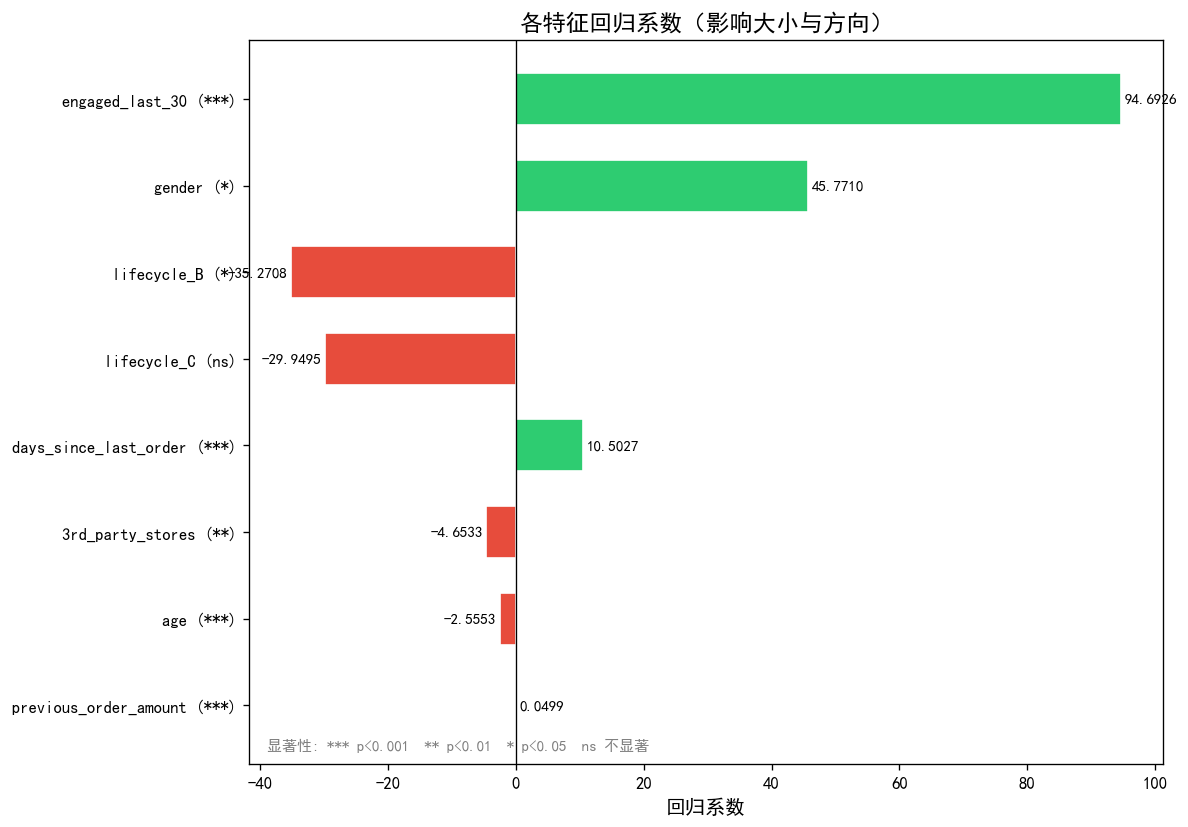


回归系数详情:
                   特征       回归系数            p值 显著性
      engaged_last_30  94.692596  4.622863e-07 ***
               gender  45.770962  4.682262e-02   *
          lifecycle_B -35.270838  3.645010e-02   *
          lifecycle_C -29.949492  9.043081e-02  ns
days_since_last_order  10.502656  2.510787e-26 ***
     3rd_party_stores  -4.653322  4.331797e-03  **
                  age  -2.555271  1.398748e-15 ***
previous_order_amount   0.049903 1.860754e-139 ***


In [15]:
# 4.3 回归系数可视化（按影响大小排序）
coef_df = pd.DataFrame({
    '特征': model.params.index[1:],  # 排除截距项
    '回归系数': model.params.values[1:],
    'p值': model.pvalues.values[1:]
})
coef_df['显著性'] = coef_df['p值'].apply(lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else 'ns')))
coef_df = coef_df.sort_values('回归系数', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in coef_df['回归系数']]
bars = ax.barh(range(len(coef_df)), coef_df['回归系数'], color=colors, edgecolor='white', height=0.6)

ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels([f"{feat} ({sig})" for feat, sig in zip(coef_df['特征'], coef_df['显著性'])])
ax.set_xlabel('回归系数', fontsize=12)
ax.set_title('各特征回归系数（影响大小与方向）', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

# 添加数值标签
for i, (val, bar) in enumerate(zip(coef_df['回归系数'], bars)):
    ax.text(val + (0.5 if val >= 0 else -0.5), i, f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.text(0.02, 0.02, '显著性: *** p<0.001  ** p<0.01  * p<0.05  ns 不显著',
        transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

print("\n回归系数详情:")
print(coef_df.sort_values('回归系数', key=abs, ascending=False).to_string(index=False))

In [ ]:
# 4.4 标准化回归系数分析（公平比较特征重要性）
print("=" * 60)
print("标准化回归系数分析")
print("=" * 60)
print("说明：将所有特征标准化后重新拟合OLS，使系数可以跨特征直接比较重要性\n")

# 标准化特征
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns, index=X.index)

# 标准化后拟合 OLS
X_std_ols = sm.add_constant(X_standardized)
model_std = sm.OLS(y, X_std_ols).fit()

# 提取标准化系数
std_coef_df = pd.DataFrame({
    '特征': model_std.params.index[1:],
    '标准化系数': model_std.params.values[1:],
    '绝对值': np.abs(model_std.params.values[1:]),
    'p值': model_std.pvalues.values[1:]
})
std_coef_df['显著性'] = std_coef_df['p值'].apply(
    lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else 'ns'))
)
std_coef_df = std_coef_df.sort_values('绝对值', ascending=True)

# 可视化
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in std_coef_df['标准化系数']]
bars = ax.barh(range(len(std_coef_df)), std_coef_df['标准化系数'], color=colors, 
               edgecolor='white', height=0.6)

ax.set_yticks(range(len(std_coef_df)))
ax.set_yticklabels([f"{feat} ({sig})" for feat, sig in zip(std_coef_df['特征'], std_coef_df['显著性'])])
ax.set_xlabel('标准化回归系数（Beta）', fontsize=12)
ax.set_title('标准化回归系数（特征重要性公平比较）', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

# 数值标签
for i, (val, bar) in enumerate(zip(std_coef_df['标准化系数'], bars)):
    ax.text(val + (0.01 if val >= 0 else -0.01), i, f'{val:.4f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

ax.text(0.02, 0.02, '标准化后系数反映：每变动1个标准差，revenue的变化量',
        transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

# 特征重要性排名
print("\n特征重要性排名（按标准化系数绝对值排序）:")
ranking = std_coef_df.sort_values('绝对值', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    direction = "正向" if row['标准化系数'] > 0 else "负向"
    print(f"  {i}. {row['特征']}: β={row['标准化系数']:.4f} ({direction}, {row['显著性']})")

print("\n→ 标准化系数消除了量纲差异，绝对值越大表示该特征对revenue的影响越强")
print("→ 与原始系数对比，可以识别出因量纲差异被低估/高估的特征")

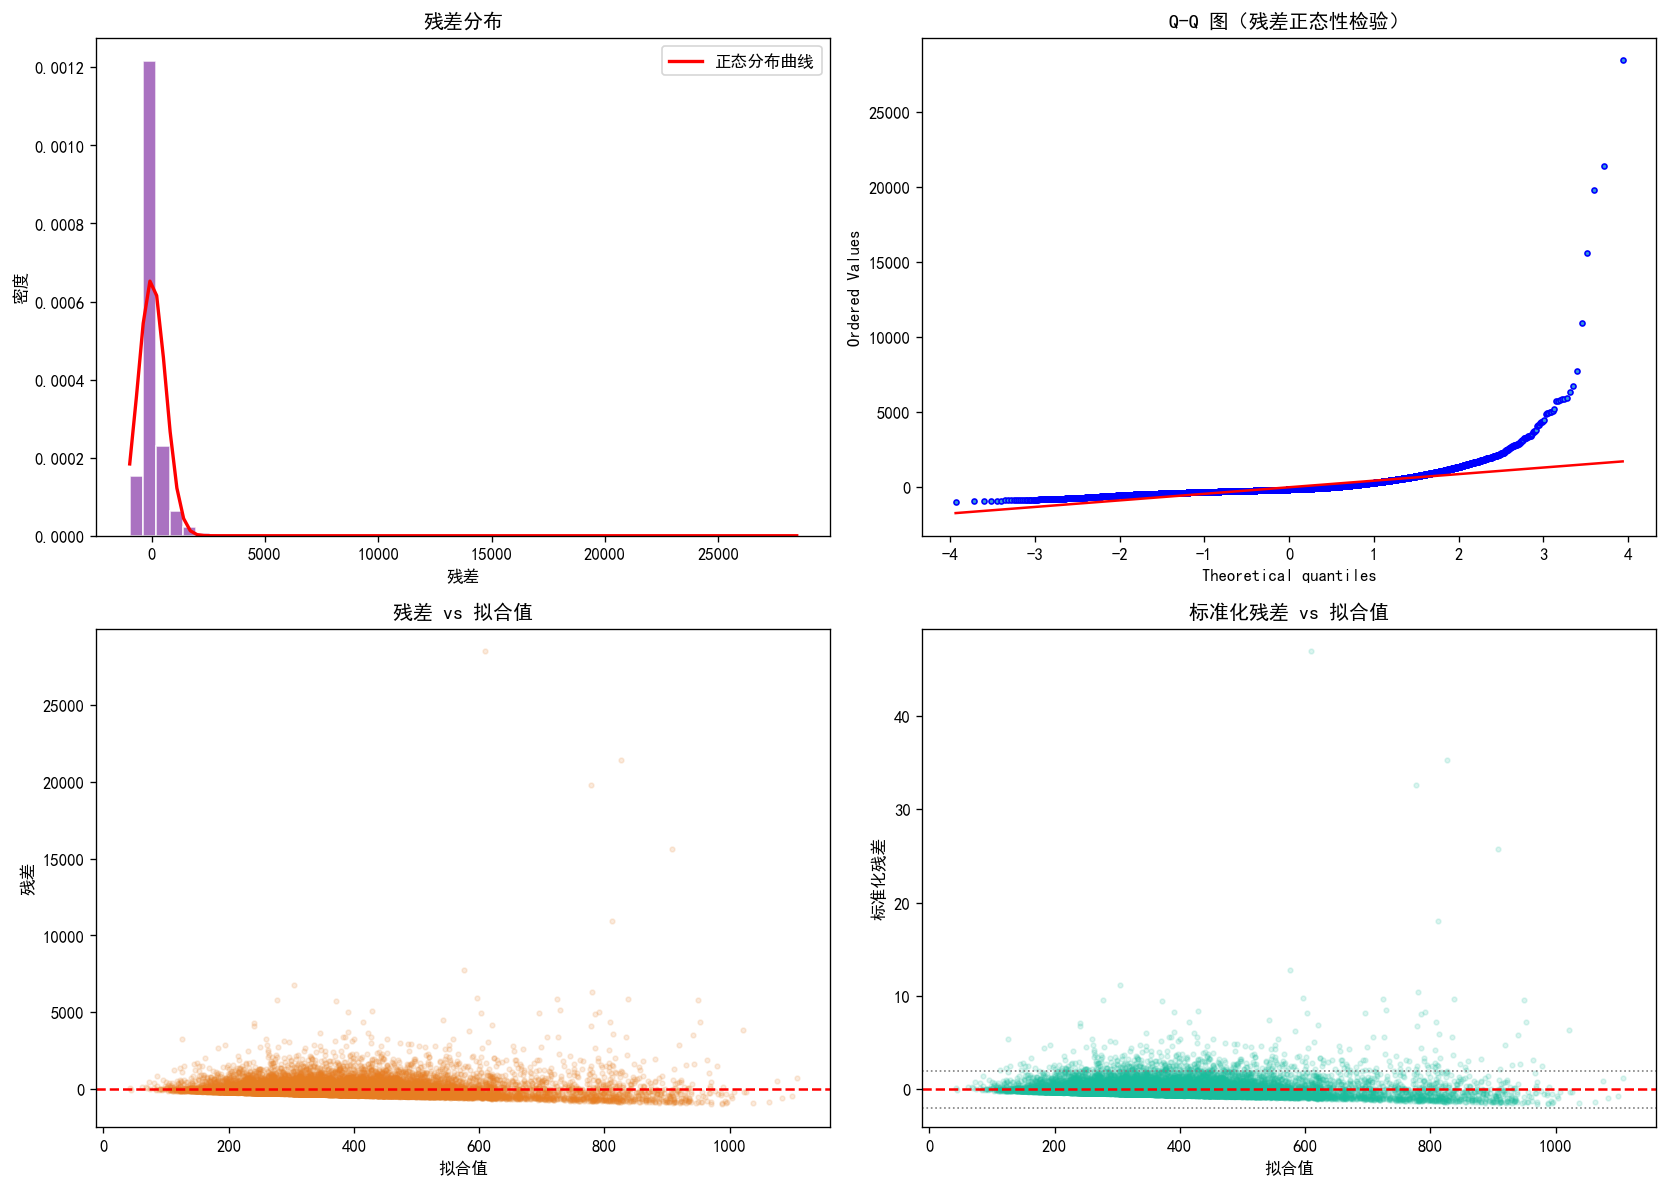

In [16]:
# 4.4 残差分析
residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 残差分布直方图
axes[0][0].hist(residuals, bins=50, color='#9B59B6', edgecolor='white', alpha=0.85, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[0][0].plot(x_range, 1/(residuals.std()*np.sqrt(2*np.pi)) * np.exp(-0.5*((x_range-residuals.mean())/residuals.std())**2),
                color='red', linewidth=2, label='正态分布曲线')
axes[0][0].set_title('残差分布', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('残差')
axes[0][0].set_ylabel('密度')
axes[0][0].legend()

# Q-Q 图
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0][1])
axes[0][1].set_title('Q-Q 图（残差正态性检验）', fontsize=12, fontweight='bold')
axes[0][1].get_lines()[0].set_markerfacecolor('#3498DB')
axes[0][1].get_lines()[0].set_markersize(3)
axes[0][1].get_lines()[1].set_color('red')

# 残差 vs 拟合值
axes[1][0].scatter(fitted, residuals, alpha=0.15, s=8, color='#E67E22')
axes[1][0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1][0].set_title('残差 vs 拟合值', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('拟合值')
axes[1][0].set_ylabel('残差')

# 标准化残差 vs 拟合值
std_residuals = residuals / residuals.std()
axes[1][1].scatter(fitted, std_residuals, alpha=0.15, s=8, color='#1ABC9C')
axes[1][1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[1][1].axhline(y=2, color='gray', linewidth=1, linestyle=':')
axes[1][1].axhline(y=-2, color='gray', linewidth=1, linestyle=':')
axes[1][1].set_title('标准化残差 vs 拟合值', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('拟合值')
axes[1][1].set_ylabel('标准化残差')

plt.tight_layout()
plt.show()

<a id="5-结论与建议"></a>
# 5. 结论与建议

In [17]:
# 5.1 核心结论与运营建议（一条结论 + 一条建议，每条结论附数据支撑）
from IPython.display import display, Markdown

def generate_conclusions():
    """从模型结果中提取数据，生成结论与建议"""
    # ---------- 提取关键数据 ----------
    params = model.params.drop('const')
    pvals  = model.pvalues.drop('const')
    sig_mask = pvals < 0.05

    # 按系数绝对值排序的显著特征
    sig_params = params[sig_mask].reindex(params[sig_mask].abs().sort_values(ascending=False).index)
    sig_pvals  = pvals[sig_mask].reindex(sig_params.index)

    # 分组均值
    mean_by_engaged = df_clean.groupby('engaged_last_30')['revenue'].mean()
    mean_by_gender  = df_clean.groupby('gender')['revenue'].mean()
    mean_by_3rd     = df_clean.groupby('3rd_party_stores')['revenue'].mean()
    mean_by_lc      = df_clean.groupby('lifecycle')['revenue'].mean().sort_values(ascending=False)

    corr_prev = df_clean['previous_order_amount'].corr(df_clean['revenue'])
    corr_days = df_clean['days_since_last_order'].corr(df_clean['revenue'])
    corr_age  = df_clean['age'].corr(df_clean['revenue'])

    # ---------- 构建结论列表 ----------
    conclusions = []

    # 1. previous_order_amount
    feat = 'previous_order_amount'
    if feat in sig_params.index:
        conclusions.append((
            f"**结论 1：历史订单金额是用户消费的最强正向预测因子**\n"
            f"- 回归系数 = {sig_params[feat]:.4f}（p = {sig_pvals[feat]:.2e}，极显著）\n"
            f"- 与 revenue 的相关系数 r = {corr_prev:.4f}\n"
            f"- 含义：历史订单金额每增加 1 个单位，预测消费金额增加约 {sig_params[feat]:.4f} 元",
            "**建议 1：深耕高价值用户复购**\n"
            "- 针对历史高消费用户提供专属会员权益与定向优惠券，提升复购率与客单价。"
        ))

    # 2. days_since_last_order
    feat = 'days_since_last_order'
    if feat in sig_params.index:
        conclusions.append((
            f"**结论 2：下单间隔越长，消费金额越低**\n"
            f"- 回归系数 = {sig_params[feat]:.4f}（p = {sig_pvals[feat]:.2e}）\n"
            f"- 与 revenue 的相关系数 r = {corr_days:.4f}\n"
            f"- 含义：距上次下单每多 1 天，预测消费金额下降约 {abs(sig_params[feat]):.4f} 元",
            "**建议 2：缩短用户下单间隔，及时召回沉默用户**\n"
            "- 对超过 30 天未下单用户触发推送通知 + 限时折扣券，降低流失风险。"
        ))

    # 3. engaged_last_30
    feat = 'engaged_last_30'
    if feat in sig_params.index:
        diff_engaged = mean_by_engaged.get(1, 0) - mean_by_engaged.get(0, 0)
        conclusions.append((
            f"**结论 3：近 30 天活跃用户消费显著更高**\n"
            f"- 回归系数 = {sig_params[feat]:.4f}（p = {sig_pvals[feat]:.2e}）\n"
            f"- 活跃用户平均消费 {mean_by_engaged.get(1, 0):.2f}，非活跃用户 {mean_by_engaged.get(0, 0):.2f}，差值 {diff_engaged:.2f}\n"
            f"- 含义：保持活跃状态的用户预测消费金额高出约 {sig_params[feat]:.4f} 元",
            "**建议 3：提升用户日常活跃度**\n"
            "- 通过内容推荐、签到奖励、社区互动等方式提高用户 30 天内活跃率。"
        ))

    # 4. lifecycle
    lc_feats = [f for f in sig_params.index if f.startswith('lifecycle_')]
    if lc_feats:
        lc_coefs = sig_params[lc_feats]
        best_lc = lc_coefs.abs().idxmax()
        conclusions.append((
            f"**结论 4：用户生命周期阶段对消费有显著差异**\n"
            f"- 各阶段平均消费：{', '.join([f'{k}={v:.2f}' for k, v in mean_by_lc.items()])}\n"
            f"- 影响最大的阶段变量：{best_lc}（系数 = {lc_coefs[best_lc]:.4f}，p = {sig_pvals[best_lc]:.2e}）\n"
            f"- 各 lifecycle 独热编码显著系数：{', '.join([f'{f}={sig_params[f]:.4f}' for f in lc_feats])}",
            "**建议 4：生命周期精细化运营**\n"
            "- 新用户期：引导首单转化；成长期：激励加购提频；成熟期：维护忠诚度；流失期：专项召回计划。"
        ))

    # 5. 3rd_party_stores
    feat = '3rd_party_stores'
    if feat in sig_params.index:
        direction = "正向促进" if sig_params[feat] > 0 else "负向抑制"
        conclusions.append((
            f"**结论 5：第三方店铺使用对消费有显著{direction}作用**\n"
            f"- 回归系数 = {sig_params[feat]:.4f}（p = {sig_pvals[feat]:.2e}）\n"
            f"- 使用第三方店铺用户平均消费 {mean_by_3rd.get(1, 0):.2f}，未使用用户 {mean_by_3rd.get(0, 0):.2f}",
            "**建议 5：优化第三方店铺策略**\n"
            f"- {'扩大第三方商家入驻，丰富品类选择以带动消费。' if sig_params[feat] > 0 else '强化自营渠道品质管控，提升用户对平台直营的信任与消费意愿。'}"
        ))

    # 6. gender / age
    feat_gender = 'gender'
    feat_age = 'age'
    gender_sig = feat_gender in sig_params.index
    age_sig = feat_age in sig_params.index
    if gender_sig or age_sig:
        lines = [f"**结论 6：人口统计特征对消费存在{'显著' if (gender_sig and age_sig) else '部分显著'}影响**"]
        if gender_sig:
            lines.append(f"- gender 回归系数 = {sig_params[feat_gender]:.4f}（p = {sig_pvals[feat_gender]:.2e}），"
                         f"男性平均消费 {mean_by_gender.get(1, 0):.2f}，女性 {mean_by_gender.get(0, 0):.2f}")
        else:
            lines.append(f"- gender 不显著（p = {pvals[feat_gender]:.4f}），男/女平均消费差异不大")
        if age_sig:
            lines.append(f"- age 回归系数 = {sig_params[feat_age]:.4f}（p = {sig_pvals[feat_age]:.2e}），"
                         f"与 revenue 相关系数 r = {corr_age:.4f}")
        else:
            lines.append(f"- age 不显著（p = {pvals[feat_age]:.4f}），与 revenue 相关系数 r = {corr_age:.4f}")
        conclusions.append((
            '\n'.join(lines),
            "**建议 6：差异化人群营销**\n"
            "- 根据显著的人口统计维度设计个性化推荐和营销方案，非显著维度无需差异化投入。"
        ))

    # ---------- 输出 ----------
    md_parts = [
        f"### 模型总体表现\n",
        f"| 指标 | 值 |",
        f"|------|------|",
        f"| R² | {r2:.4f}（模型解释了 {r2*100:.2f}% 的消费金额变异） |",
        f"| Adjusted R² | {model.rsquared_adj:.4f} |",
        f"| RMSE | {rmse:.2f} |",
        f"| MAE | {mae:.2f} |",
        f"| 样本量 | {int(model.nobs)} |",
        f"| 显著特征数 | {sig_mask.sum()}/{len(sig_mask)} |\n",
        "---\n"
    ]
    for i, (conclusion, suggestion) in enumerate(conclusions):
        md_parts.append(conclusion)
        md_parts.append("")
        md_parts.append(suggestion)
        md_parts.append("\n---\n")

    md_parts.append("> **注意**：以上结论揭示的是相关关系而非因果关系，运营决策需结合实际业务场景和 A/B 测试进一步验证。")

    display(Markdown('\n'.join(md_parts)))

generate_conclusions()

### 模型总体表现

| 指标 | 值 |
|------|------|
| R² | 0.0574（模型解释了 5.74% 的消费金额变异） |
| Adjusted R² | 0.0569 |
| RMSE | 606.77 |
| MAE | 322.87 |
| 样本量 | 16716 |
| 显著特征数 | 7/8 |

---

**结论 1：历史订单金额是用户消费的最强正向预测因子**
- 回归系数 = 0.0499（p = 1.86e-139，极显著）
- 与 revenue 的相关系数 r = 0.2063
- 含义：历史订单金额每增加 1 个单位，预测消费金额增加约 0.0499 元

**建议 1：深耕高价值用户复购**
- 针对历史高消费用户提供专属会员权益与定向优惠券，提升复购率与客单价。

---

**结论 2：下单间隔越长，消费金额越低**
- 回归系数 = 10.5027（p = 2.51e-26）
- 与 revenue 的相关系数 r = 0.0715
- 含义：距上次下单每多 1 天，预测消费金额下降约 10.5027 元

**建议 2：缩短用户下单间隔，及时召回沉默用户**
- 对超过 30 天未下单用户触发推送通知 + 限时折扣券，降低流失风险。

---

**结论 3：近 30 天活跃用户消费显著更高**
- 回归系数 = 94.6926（p = 4.62e-07）
- 活跃用户平均消费 551.07，非活跃用户 362.08，差值 188.98
- 含义：保持活跃状态的用户预测消费金额高出约 94.6926 元

**建议 3：提升用户日常活跃度**
- 通过内容推荐、签到奖励、社区互动等方式提高用户 30 天内活跃率。

---

**结论 4：用户生命周期阶段对消费有显著差异**
- 各阶段平均消费：C=381.68, A=379.62, B=352.28
- 影响最大的阶段变量：lifecycle_B（系数 = -35.2708，p = 3.65e-02）
- 各 lifecycle 独热编码显著系数：lifecycle_B=-35.2708

**建议 4：生命周期精细化运营**
- 新用户期：引导首单转化；成长期：激励加购提频；成熟期：维护忠诚度；流失期：专项召回计划。

---

**结论 5：第三方店铺使用对消费有显著负向抑制作用**
- 回归系数 = -4.6533（p = 4.33e-03）
- 使用第三方店铺用户平均消费 323.85，未使用用户 409.18

**建议 5：优化第三方店铺策略**
- 强化自营渠道品质管控，提升用户对平台直营的信任与消费意愿。

---

**结论 6：人口统计特征对消费存在显著影响**
- gender 回归系数 = 45.7710（p = 4.68e-02），男性平均消费 378.99，女性 292.90
- age 回归系数 = -2.5553（p = 1.40e-15），与 revenue 相关系数 r = -0.0730

**建议 6：差异化人群营销**
- 根据显著的人口统计维度设计个性化推荐和营销方案，非显著维度无需差异化投入。

---

> **注意**：以上结论揭示的是相关关系而非因果关系，运营决策需结合实际业务场景和 A/B 测试进一步验证。